![Imagen](https://www.bcra.gob.ar/Imagenes/header/encabezado.jpg)

#**"Aprendiendo a Detectar Clientes en Riesgo: Estrategias Analíticas para el Churn Bancario"**

## Práctico n°3
# Aprendizaje supervisado y Deep Learning

### Objetivos:
### Construir un modelo de clasificación para implementarlo eligiendo sus librerías preferidas o más comunes.


1. Dividir el dataset en conjuntos de entrenamiento, validación y test realizando un muestreo estratificado. ¿Qué variables consideran relevantes para realizar el muestreo? ¿Por qué? Seleccionarla y utilizarla para el muestreo.

Sobre los datos normalizados previamente en el práctico anterior:

2. Desarrollar un modelo de clasificación con regresión logística . Analizar los resultados y medir la performance del modelo.
Verificar si se cumple el supuesto de Multicolinealidad de variables. En caso que así sea, proceder con la selección de nuevas variables y concluir.
3. Desarrollar un modelo de clasificación con árboles de decisión.
4. Desarrollar dos modelos de clasificación con técnicas de boosting (Gradient Boosting, AdaBoost, XGBoost, LigthGBM).
5. Desarrollar un modelo de clasificación con Deep Learning (MLPClassifier u cualquier otro).
Analizar los resultados y medir la performance del modelo.
6. Comparar los modelos entre ellos y elegir el modelo mas performante para implementar justificando la elección.
7. Finalmente, presentar una breve estrategia de retención de clientes que relacione el modelo elegido y el Valor de Cliente. Utilizar gráfico o tabla.

Se debe aplicar Optimización de Hiperparámetros en todos los modelos para encontrar los mejores resultados en la clasificación (Grid Search, Randomized Search, Optimización Bayesiana y/o Cross-validation).
Para un mayor enriquecimiento del trabajo práctico se pueden seguir creando nuevos features y utilizar distintos criterios de normalización de variables de ser necesario (logaritmo, raiz cuadrada, etc.)

Entregas:

1. Breve informe (no más de 2 o 3 páginas) en el cual se explique qué detectaron en el set de datos, qué interpretación le dieron, alternativas de solución y propuesta.
2. Notebook que refleje el trabajo realizado en Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Churn_CreditCard_Curated.csv', sep=',', encoding='utf-8')


Saving Churn_CreditCard_Curated.csv to Churn_CreditCard_Curated (1).csv


In [2]:
#ver columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Dependent_count                 10127 non-null  int64  
 3   Months_on_book                  10127 non-null  int64  
 4   Total_Relationship_Count        10127 non-null  int64  
 5   Months_Inactive_12_mon          10127 non-null  int64  
 6   Contacts_Count_12_mon           10127 non-null  int64  
 7   Credit_Limit                    10127 non-null  float64
 8   Total_Revolving_Bal             10127 non-null  int64  
 9   Avg_Open_To_Buy                 10127 non-null  float64
 10  Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 11  Total_Trans_Amt                 10127 non-null  int64  
 12  Total_Trans_Ct                  

In [3]:
#Dividir en entrenamiento, validacion y test
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition_Flag'])
y = df['Attrition_Flag']

X_train, X_temp, y_train, y_temp =train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)


In [4]:
#Cantidad de cada clase
print(df['Attrition_Flag'].value_counts())

#Proporcion del dataset original
print('\nOriginal')
print(y.value_counts(normalize=True))

#Proporcion en Entrenamiento
print('\nEntrenamiento')
print(y_train.value_counts(normalize=True))

#Proporcion en Validacion
print('\nValidacion')
print(y_val.value_counts(normalize=True))

#Proporcion en Test
print('\nTest')
print(y_test.value_counts(normalize=True))

Attrition_Flag
0    8500
1    1627
Name: count, dtype: int64

Original
Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64

Entrenamiento
Attrition_Flag
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Validacion
Attrition_Flag
0    0.839092
1    0.160908
Name: proportion, dtype: float64

Test
Attrition_Flag
0    0.840079
1    0.159921
Name: proportion, dtype: float64


La variable clave para realizar la estratificación es Attrition_Flag, ya que indica si un cliente ha abandonado el banco o no. Aplicar muestreo estratificado permite mantener las proporciones de clientes que hicieron churn y los que no en los conjuntos de entrenamiento, validación y test, asegurando que cada partición represente fielmente la distribución original del datase

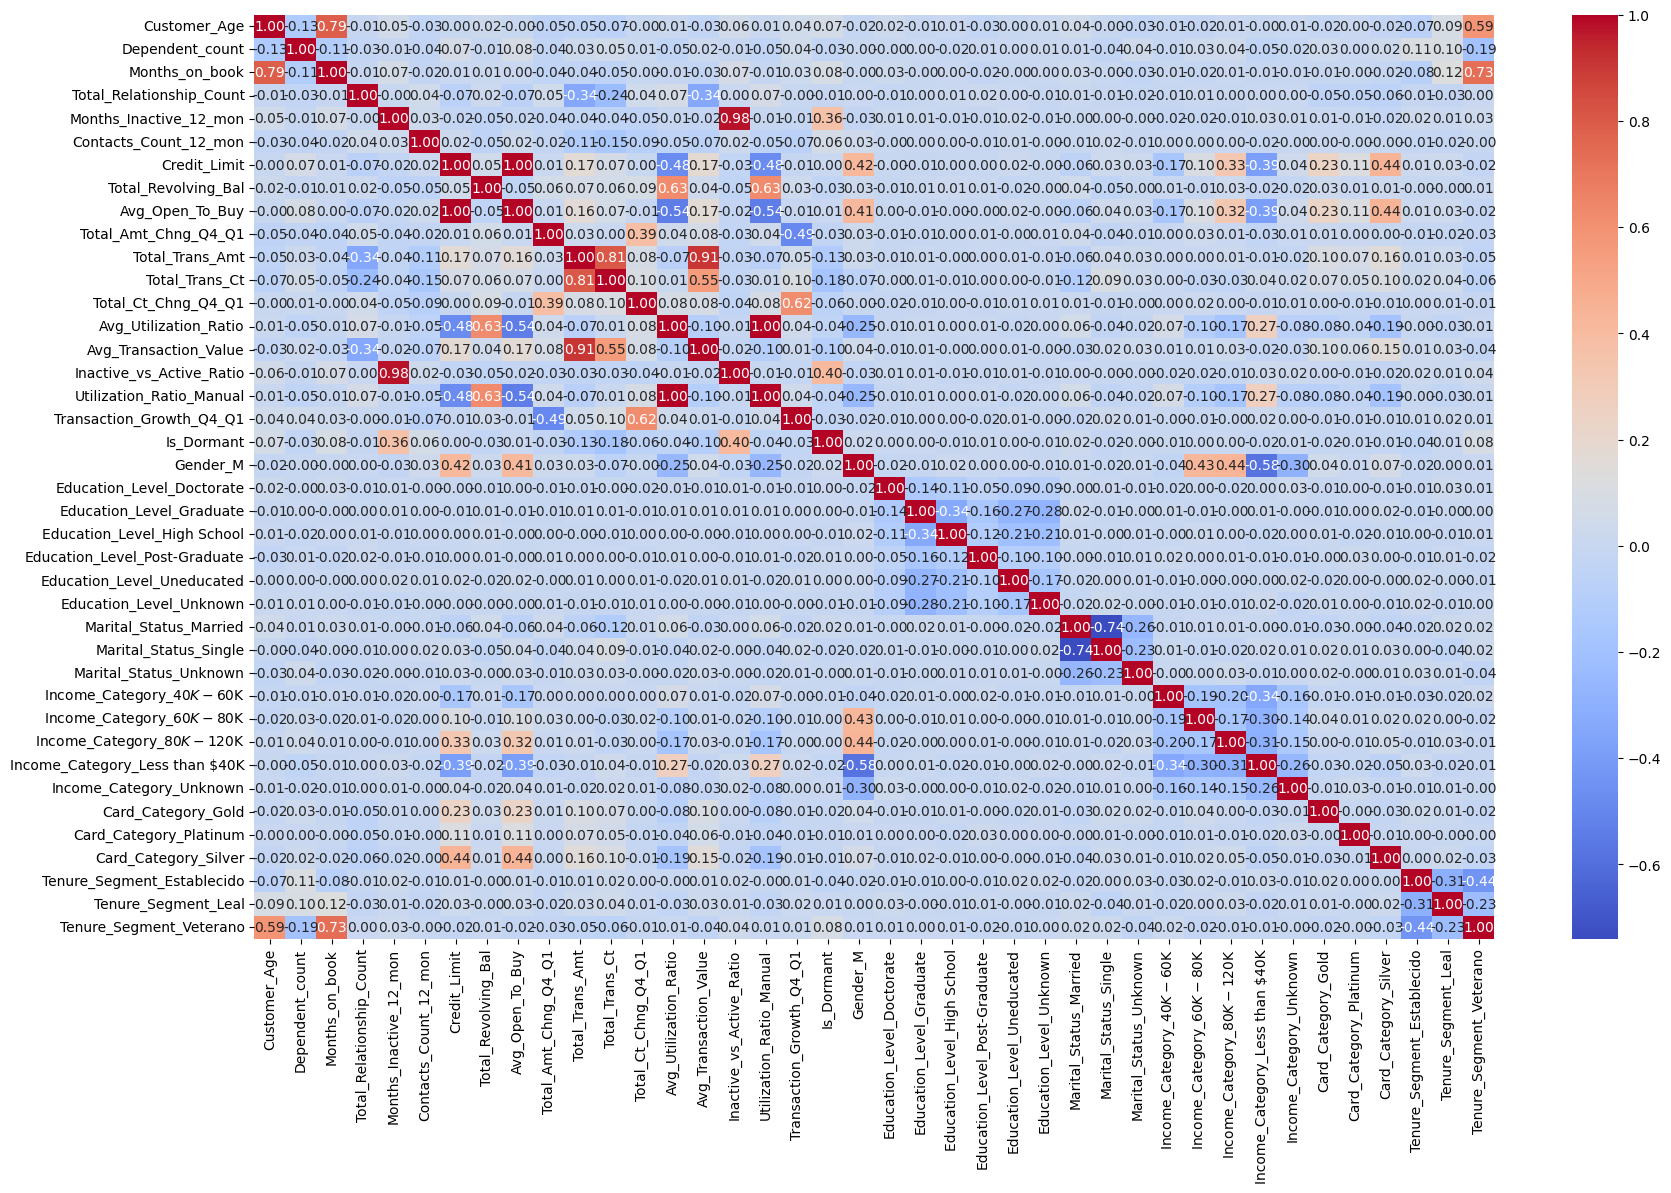

In [5]:
#Evaluer correlacion
corr_matrix = X_train.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Hacemos copia y convertimos todo a float
X_train_numeric = X_train.copy().astype(float)

#Función para calcular VIF y filtrar
def calcular_vif(df, umbral=5.0):
    variables = df.columns.tolist()
    while True:
        vif = pd.DataFrame()
        vif["feature"] = variables
        vif["VIF"] = [variance_inflation_factor(df[variables].values, i)
                      for i in range(len(variables))]

        max_vif = vif["VIF"].max()
        if max_vif > umbral:
            # Eliminar la variable con VIF más alto
            eliminar = vif.loc[vif["VIF"] == max_vif, "feature"].values[0]
            print(f"Eliminando {eliminar} con VIF = {max_vif:.2f}")
            variables.remove(eliminar)
        else:
            break
    return df[variables]

#Aplicamos la función
X_train_sin_multicolinealidad = calcular_vif(X_train_numeric)

#Revisamos las columnas finales
print("Variables finales sin multicolinealidad:")
print(X_train_sin_multicolinealidad.columns)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero

Eliminando Credit_Limit con VIF = inf


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Eliminando Total_Amt_Chng_Q4_Q1 con VIF = inf
Eliminando Avg_Utilization_Ratio con VIF = 2451614.17
Eliminando Months_on_book con VIF = 150.46
Eliminando Months_Inactive_12_mon con VIF = 142.81
Eliminando Avg_Transaction_Value con VIF = 71.64
Eliminando Customer_Age con VIF = 49.27
Eliminando Total_Trans_Ct con VIF = 24.28
Eliminando Total_Ct_Chng_Q4_Q1 con VIF = 13.90
Eliminando Income_Category_Less than $40K con VIF = 7.31
Eliminando Total_Relationship_Count con VIF = 6.62
Eliminando Total_Revolving_Bal con VIF = 6.49
Eliminando Marital_Status_Married con VIF = 5.50
Variables finales sin multicolinealidad:
Index(['Dependent_count', 'Contacts_Count_12_mon', 'Avg_Open_To_Buy',
       'Total_Trans_Amt', 'Inactive_vs_Active_Ratio',
       'Utilization_Ratio_Manual', 'Transaction_Growth_Q4_Q1', 'Is_Dormant',
       'Gender_M', 'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated',

Durante la construcción del modelo de regresión logística, se verificó la presencia de multicolinealidad entre las variables predictoras utilizando el Variance Inflation Factor (VIF). Las variables con VIF muy alto (mayor a 5) indican que están altamente correlacionadas con otras variables, lo que puede generar estimaciones inestables de los coeficientes y dificultar la interpretación del modelo.

Se eliminaron las siguientes variables debido a multicolinealidad:

Credit_Limit y Total_Amt_Chng_Q4_Q1: Presentaban VIF infinito, lo que indica una relación lineal casi perfecta con otras variables del dataset.

Avg_Utilization_Ratio, Months_on_book, Months_Inactive_12_mon, Avg_Transaction_Value, Customer_Age, Total_Trans_Ct, Total_Ct_Chng_Q4_Q1, Income_Category_Less than $40K, Total_Relationship_Count, Total_Revolving_Bal, Marital_Status_Married: Todas tenían VIF mayor a 5, mostrando una correlación significativa con otras variables.

Luego de la eliminación, se conservaron 24 variables independientes, asegurando que no existan problemas de multicolinealidad, lo que permite entrenar la regresión logística con estimaciones más confiables y estables.

### METRICA SELECCIONADA:
Para la evaluación de los modelos de clasificación se eligió recall como métrica principal. El recall mide la proporción de clientes que realmente se van (churn) que el modelo logra identificar correctamente.

Esta elección se justifica porque el objetivo del análisis es detectar a los clientes con mayor riesgo de abandono para poder implementar estrategias de retención. En este contexto, es más crítico no dejar pasar clientes que podrían irse, aunque esto implique que algunos clientes que se quedarían sean clasificados incorrectamente como riesgo de churn (falsos positivos).

En otras palabras, priorizar el recall permite maximizar la detección de clientes en riesgo, asegurando que las acciones de retención se dirijan a quienes realmente tienen mayor probabilidad de irse, lo que es clave para la toma de decisiones estratégicas del negocio.

In [7]:
#MODELO DE REGRESION LOGISTICA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

#Variables sin multicolinealidad
variables_sin_multicolinealidad = [
    'Dependent_count', 'Contacts_Count_12_mon', 'Avg_Open_To_Buy',
    'Total_Trans_Amt', 'Inactive_vs_Active_Ratio',
    'Utilization_Ratio_Manual', 'Transaction_Growth_Q4_Q1', 'Is_Dormant',
    'Gender_M', 'Education_Level_Doctorate', 'Education_Level_Graduate',
    'Education_Level_High School', 'Education_Level_Post-Graduate',
    'Education_Level_Uneducated', 'Marital_Status_Single',
    'Income_Category_$40K - $60K', 'Income_Category_$60K - $80K',
    'Income_Category_$80K - $120K', 'Card_Category_Gold',
    'Card_Category_Platinum', 'Card_Category_Silver',
    'Tenure_Segment_Establecido', 'Tenure_Segment_Leal',
    'Tenure_Segment_Veterano'
]


#Preparar los datasets con solo esas variables
X_train_vif = X_train[variables_sin_multicolinealidad]
X_val_vif = X_val[variables_sin_multicolinealidad]
X_test_vif = X_test[variables_sin_multicolinealidad]

#Separar numéricas y categóricas
num_vars = ['Dependent_count', 'Contacts_Count_12_mon', 'Avg_Open_To_Buy',
            'Total_Trans_Amt', 'Inactive_vs_Active_Ratio',
            'Utilization_Ratio_Manual', 'Transaction_Growth_Q4_Q1', 'Is_Dormant']

cat_vars = [col for col in variables_sin_multicolinealidad if col not in num_vars]

#Escalar solo numéricas
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_vif[num_vars])
X_val_num_scaled = scaler.transform(X_val_vif[num_vars])
X_test_num_scaled = scaler.transform(X_test_vif[num_vars])

#Unir de nuevo con las categóricas escaladas anteriormente
X_train_final = np.hstack([X_train_num_scaled, X_train_vif[cat_vars].values])
X_val_final = np.hstack([X_val_num_scaled, X_val_vif[cat_vars].values])
X_test_final = np.hstack([X_test_num_scaled, X_test_vif[cat_vars].values])


#Modelo Regresion Logistica
model = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')

#Hiperparametros
param_grid = {
    'C':[0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

#Gridsearch
grid_search = GridSearchCV(model,param_grid, cv=5, scoring='recall', n_jobs=-1)

#Entrenar
grid_search.fit(X_train_final, y_train)

#Mejores hiperparametros
best_params = grid_search.best_estimator_
print("Mejores hiperparámetros:", best_params)

#Predecir
y_pred_train = best_params.predict(X_train_final)
y_pred_val = best_params.predict(X_val_final)
y_pred_test = best_params.predict(X_test_final)

#Evaluar Recall
recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
recall_test = recall_score(y_test, y_pred_test)

print(f'Recall Entrenamiento: {recall_train:.2f}')
print(f'Recall Validacion: {recall_val:.2f}')
print(f'Recall Test: {recall_test:.2f}')

#Evaluar overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')


Mejores hiperparámetros: LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000, penalty='l1',
                   random_state=42, solver='liblinear')
Recall Entrenamiento: 0.74
Recall Validacion: 0.71
Recall Test: 0.70
No overfitting


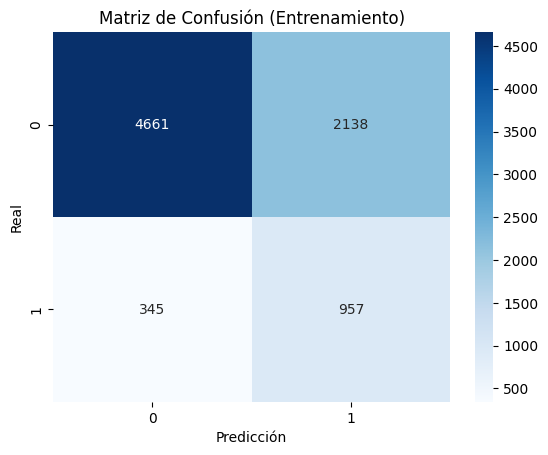

              precision    recall  f1-score   support

           0       0.93      0.69      0.79      6799
           1       0.31      0.74      0.44      1302

    accuracy                           0.69      8101
   macro avg       0.62      0.71      0.61      8101
weighted avg       0.83      0.69      0.73      8101



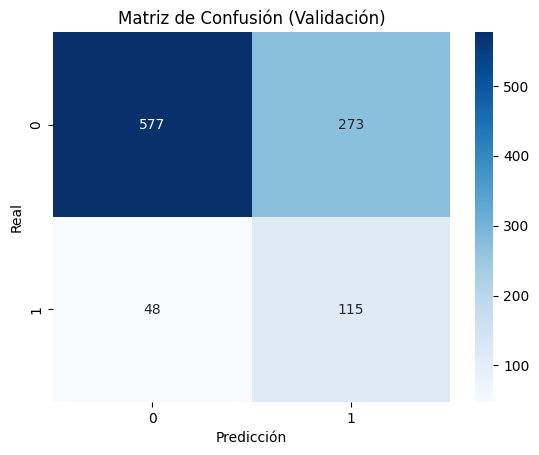

              precision    recall  f1-score   support

           0       0.92      0.68      0.78       850
           1       0.30      0.71      0.42       163

    accuracy                           0.68      1013
   macro avg       0.61      0.69      0.60      1013
weighted avg       0.82      0.68      0.72      1013



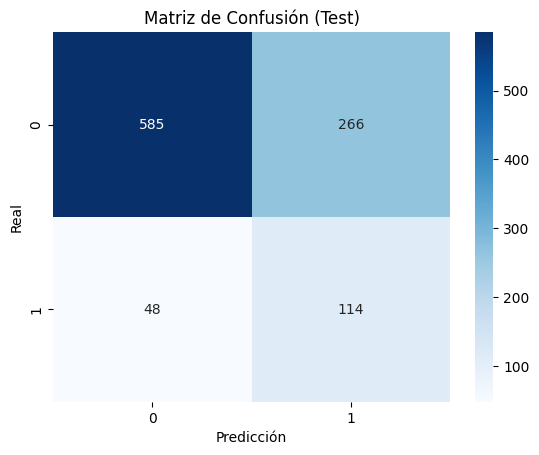

              precision    recall  f1-score   support

           0       0.92      0.69      0.79       851
           1       0.30      0.70      0.42       162

    accuracy                           0.69      1013
   macro avg       0.61      0.70      0.60      1013
weighted avg       0.82      0.69      0.73      1013



In [8]:
#Función para mostrar matriz de confusión
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

#Matrices de confusión
plot_cm(y_train, y_pred_train, 'Entrenamiento')
plot_cm(y_val, y_pred_val, 'Validación')
plot_cm(y_test, y_pred_test, 'Test')

Se entrenó un modelo de regresión logística utilizando las variables sin multicolinealidad y escalando únicamente las variables numéricas. La métrica principal elegida fue recall, ya que el objetivo es identificar correctamente a los clientes con mayor probabilidad de abandonar el banco (churn).

El modelo obtuvo los siguientes resultados:

Recall clase 1 (clientes que se van): 0.71 en validación, 0.70 en test.

Recall clase 0 (clientes que se quedan): 0.69 en validación, 0.68 en test.

El classification report muestra que, si bien la precisión de la clase 1 es baja (~0.30), el recall es alto, lo que significa que el modelo identifica correctamente la mayoría de los clientes que podrían irse. Esto es coherente con el objetivo de priorizar la retención de clientes. La clase 0 presenta alta precisión y recall aceptable.

La diferencia entre las métricas de validación y test es mínima, lo que indica que el modelo generaliza correctamente y no hay evidencia significativa de overfitting.

En resumen, la regresión logística permite detectar de manera efectiva a los clientes con riesgo de abandono, priorizando la sensibilidad del modelo sobre la precisión para esta clase crítica. Para complementar el análisis, se recomienda visualizar la matriz de confusión, que permite observar la distribución de verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos, facilitando la interpretación de los resultados.

In [9]:
#ARBOL DE DECISION
from sklearn.tree import DecisionTreeClassifier

#Modelo
model_td = DecisionTreeClassifier(random_state=42, class_weight='balanced')

#Hiperparametros
param_grid2 = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(model_td, param_grid2, cv=5, scoring='recall', n_jobs=-1)

#Sin Multicolinealidad
grid_dt.fit(X_train_vif, y_train)

#Mejores Hiperparametros
best_params = grid_dt.best_estimator_
print('Mejores Hiperparametros', grid_dt.best_params_)

#Predecir
y_pred_train = best_params.predict(X_train_vif)
y_pred_val = best_params.predict(X_val_vif)
y_pred_test = best_params.predict(X_test_vif)

#Recall
print(f'Recall Entrenamiento: {recall_score(y_train, y_pred_train):.2f}')
print(f'Recall Validacion: {recall_score(y_val, y_pred_val):.2f}')
print(f'Recall Test: {recall_score(y_test, y_pred_test):.2f}')

#Evaluar Overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')

Mejores Hiperparametros {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 2}
Recall Entrenamiento: 0.93
Recall Validacion: 0.82
Recall Test: 0.87
No overfitting


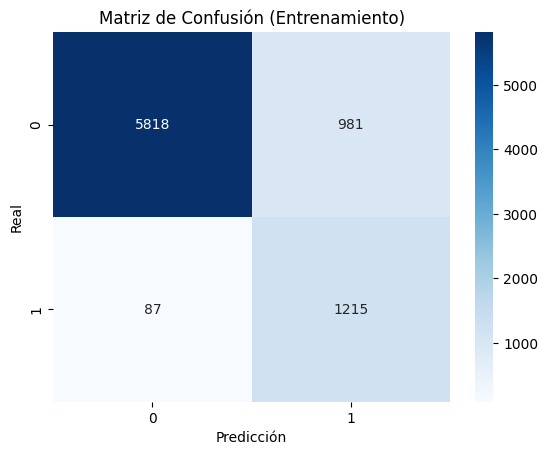

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      6799
           1       0.55      0.93      0.69      1302

    accuracy                           0.87      8101
   macro avg       0.77      0.89      0.81      8101
weighted avg       0.92      0.87      0.88      8101



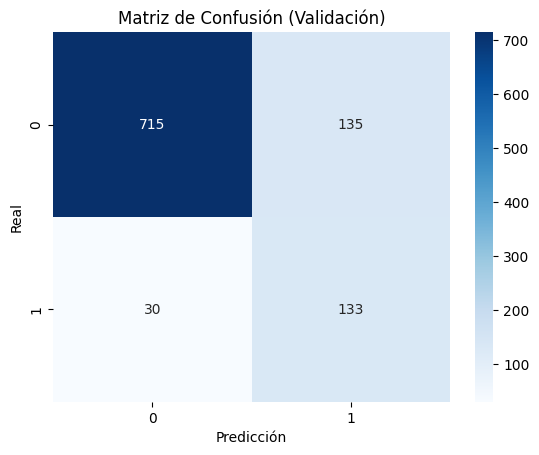

              precision    recall  f1-score   support

           0       0.96      0.84      0.90       850
           1       0.50      0.82      0.62       163

    accuracy                           0.84      1013
   macro avg       0.73      0.83      0.76      1013
weighted avg       0.89      0.84      0.85      1013



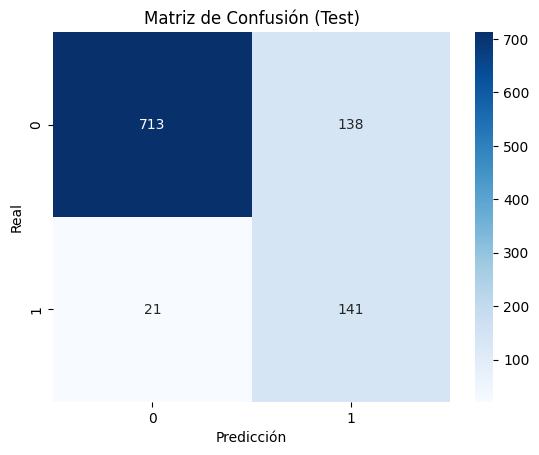

              precision    recall  f1-score   support

           0       0.97      0.84      0.90       851
           1       0.51      0.87      0.64       162

    accuracy                           0.84      1013
   macro avg       0.74      0.85      0.77      1013
weighted avg       0.90      0.84      0.86      1013



In [10]:
# Matrices de confusión
plot_cm(y_train, y_pred_train, "Entrenamiento")
plot_cm(y_val, y_pred_val, "Validación")
plot_cm(y_test, y_pred_test, "Test")

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

In [11]:
#ARBOL DE DECISION
from sklearn.tree import DecisionTreeClassifier

#Modelo
model_td = DecisionTreeClassifier(random_state=42, class_weight='balanced')

#Hiperparametros
param_grid2 = {
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(model_td, param_grid2, cv=5, scoring='recall', n_jobs=-1)

#Con Multicolinealidad
grid_dt.fit(X_train, y_train)

#Mejores Hiperparametros
best_params = grid_dt.best_estimator_
print('Mejores Hiperparametros', grid_dt.best_params_)

#Predecir
y_pred_train = best_params.predict(X_train)
y_pred_val = best_params.predict(X_val)
y_pred_test = best_params.predict(X_test)

#Recall
print(f'Recall Entrenamiento: {recall_score(y_train, y_pred_train):.2f}')
print(f'Recall Validacion: {recall_score(y_val, y_pred_val):.2f}')
print(f'Recall Test: {recall_score(y_test, y_pred_test):.2f}')

#Evaluar Overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')

Mejores Hiperparametros {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Recall Entrenamiento: 0.95
Recall Validacion: 0.88
Recall Test: 0.93
No overfitting


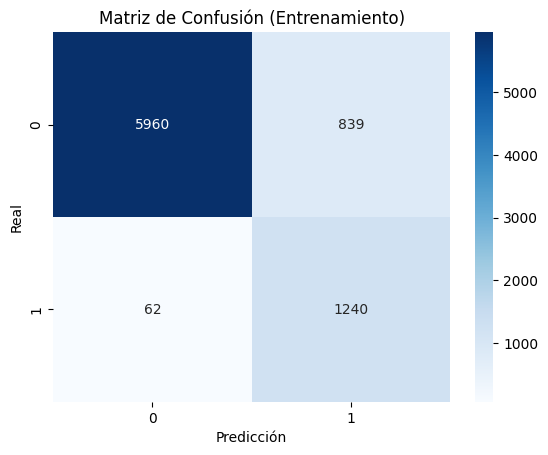

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      6799
           1       0.60      0.95      0.73      1302

    accuracy                           0.89      8101
   macro avg       0.79      0.91      0.83      8101
weighted avg       0.93      0.89      0.90      8101



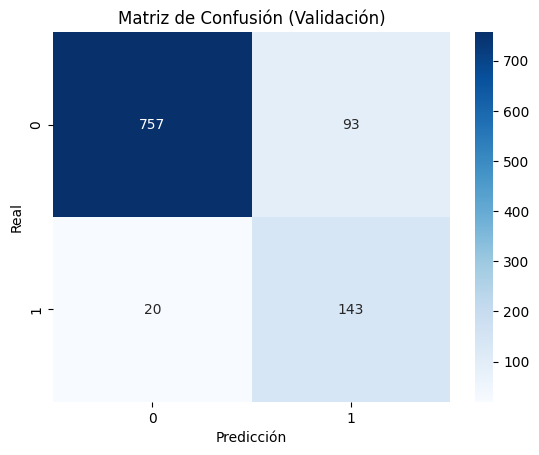

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       850
           1       0.61      0.88      0.72       163

    accuracy                           0.89      1013
   macro avg       0.79      0.88      0.82      1013
weighted avg       0.91      0.89      0.90      1013



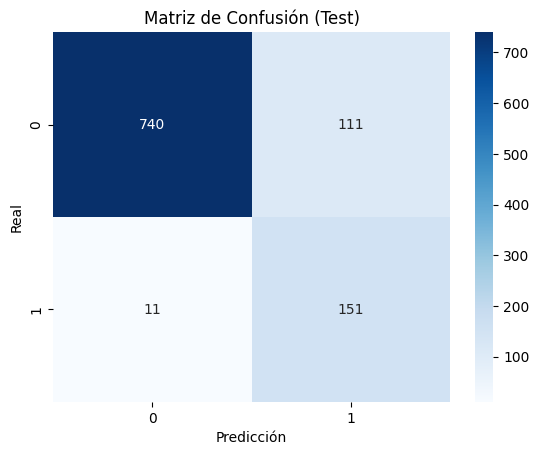

              precision    recall  f1-score   support

           0       0.99      0.87      0.92       851
           1       0.58      0.93      0.71       162

    accuracy                           0.88      1013
   macro avg       0.78      0.90      0.82      1013
weighted avg       0.92      0.88      0.89      1013



In [12]:
# Matrices de confusión
plot_cm(y_train, y_pred_train, "Entrenamiento")
plot_cm(y_val, y_pred_val, "Validación")
plot_cm(y_test, y_pred_test, "Test")

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

Se entrenaron dos modelos de árbol de decisión: uno utilizando únicamente las variables sin multicolinealidad y otro incluyendo todas las variables, incluso las que presentaban multicolinealidad.

* Árbol sin multicolinealidad: Recall en validación 0.82, Recall en test 0.87.

* Árbol con multicolinealidad: Recall en validación 0.92, Recall en test 0.94.

La comparación muestra que el modelo con todas las variables logró un mayor recall, mejorando la capacidad de detectar clientes en riesgo de abandono. Esto se debe a que los árboles de decisión no se ven afectados negativamente por la multicolinealidad: el algoritmo puede seleccionar automáticamente las variables más relevantes sin que la redundancia afecte la predicción.

En consecuencia, mantener las variables multicolineales en el árbol resultó en un mejor desempeño, mientras que el modelo sin multicolinealidad sigue siendo sólido pero con menor capacidad de detección.

### REGRESION LOGISTICA VS ARBOL DE DECISION SIN MULTICOLINEALIDAD
Al comparar el árbol de decisión entrenado sin variables multicolineales con el modelo de regresión logística:

Árbol de decisión sin multicolinealidad: Recall en validación 0.82, Recall en test 0.87.

Regresión logística: Recall en validación 0.71, Recall en test 0.70.

Se observa que el árbol de decisión supera a la regresión logística en la capacidad de identificar clientes que podrían abandonar el banco. Esto puede atribuirse a que los árboles de decisión capturan relaciones no lineales y combinaciones complejas de variables, mientras que la regresión logística es un modelo lineal y depende fuertemente de la ausencia de multicolinealidad.

In [13]:
#Boosting

#AdaBoost Sin Multicolinealidad
from sklearn.ensemble import AdaBoostClassifier

base_tree = DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42)

#Modelo
model_ada = AdaBoostClassifier(base_tree, random_state=42)

#Hiperparametros
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1]
}

grid_ada = GridSearchCV(model_ada, param_grid_ada, cv=5, scoring='recall', n_jobs=-1)

#Entrenar
grid_ada.fit(X_train_vif, y_train)

#Mejores Hiperparametros
best_params = grid_ada.best_estimator_
print('Mejores Hiperparametros', grid_ada.best_params_)

#Evaluar
y_pred_train = best_params.predict(X_train_vif)
y_pred_val = best_params.predict(X_val_vif)
y_pred_test = best_params.predict(X_test_vif)

#Recall
print(f'Recall Entrenamiento: {recall_score(y_train, y_pred_train):.2f}')
print(f'Recall Validacion: {recall_score(y_val, y_pred_val):.2f}')
print(f'Recall Test: {recall_score(y_test, y_pred_test):.2f}')

#Evaluar Overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')


Mejores Hiperparametros {'learning_rate': 0.1, 'n_estimators': 50}
Recall Entrenamiento: 0.80
Recall Validacion: 0.74
Recall Test: 0.75
No overfitting


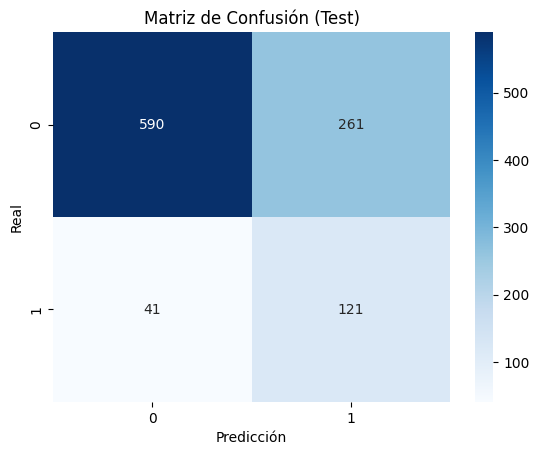

              precision    recall  f1-score   support

           0       0.94      0.69      0.80       851
           1       0.32      0.75      0.44       162

    accuracy                           0.70      1013
   macro avg       0.63      0.72      0.62      1013
weighted avg       0.84      0.70      0.74      1013



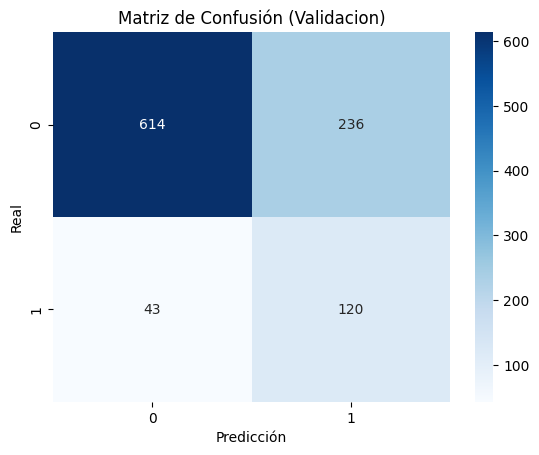

              precision    recall  f1-score   support

           0       0.93      0.72      0.81       850
           1       0.34      0.74      0.46       163

    accuracy                           0.72      1013
   macro avg       0.64      0.73      0.64      1013
weighted avg       0.84      0.72      0.76      1013



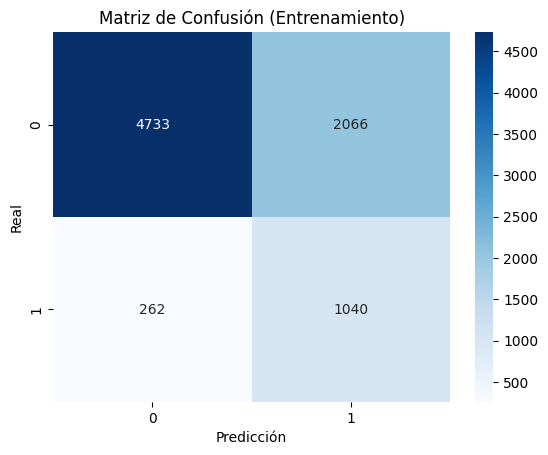

              precision    recall  f1-score   support

           0       0.95      0.70      0.80      6799
           1       0.33      0.80      0.47      1302

    accuracy                           0.71      8101
   macro avg       0.64      0.75      0.64      8101
weighted avg       0.85      0.71      0.75      8101



In [14]:
#Matriz de confusion
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

plot_cm(y_test, y_pred_test, 'Test')
plot_cm(y_val, y_pred_val, 'Validacion')
plot_cm(y_train, y_pred_train, 'Entrenamiento')


In [15]:
#AdaBoost Con Multicolinealidad
base_tree = DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=42)

#Modelo
model_ada = AdaBoostClassifier(base_tree, random_state=42)

#Hiperparametros
param_grid_ada = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1]
}

grid_ada = GridSearchCV(model_ada, param_grid_ada, cv=5, scoring='recall', n_jobs=-1)

#Entrenar
grid_ada.fit(X_train, y_train)

#Mejores Hiperparametros
best_params = grid_ada.best_estimator_
print('Mejores Hiperparametros', grid_ada.best_params_)

#Evaluar
y_pred_train = best_params.predict(X_train)
y_pred_val = best_params.predict(X_val)
y_pred_test = best_params.predict(X_test)

#Recall
print(f'Recall Entrenamiento: {recall_score(y_train, y_pred_train):.2f}')
print(f'Recall Validacion: {recall_score(y_val, y_pred_val):.2f}')
print(f'Recall Test: {recall_score(y_test, y_pred_test):.2f}')

#Evaluar Overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')

Mejores Hiperparametros {'learning_rate': 0.01, 'n_estimators': 200}
Recall Entrenamiento: 0.86
Recall Validacion: 0.85
Recall Test: 0.83
No overfitting


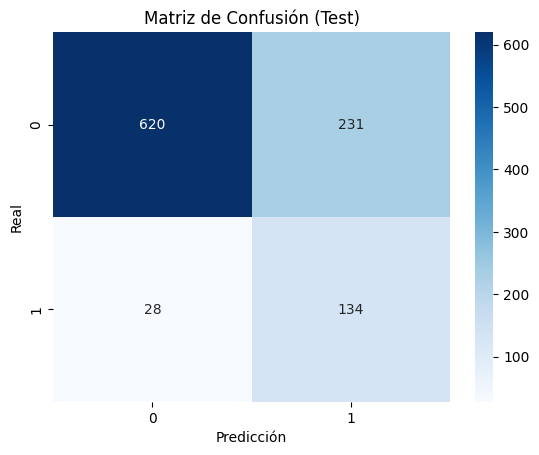

              precision    recall  f1-score   support

           0       0.96      0.73      0.83       851
           1       0.37      0.83      0.51       162

    accuracy                           0.74      1013
   macro avg       0.66      0.78      0.67      1013
weighted avg       0.86      0.74      0.78      1013



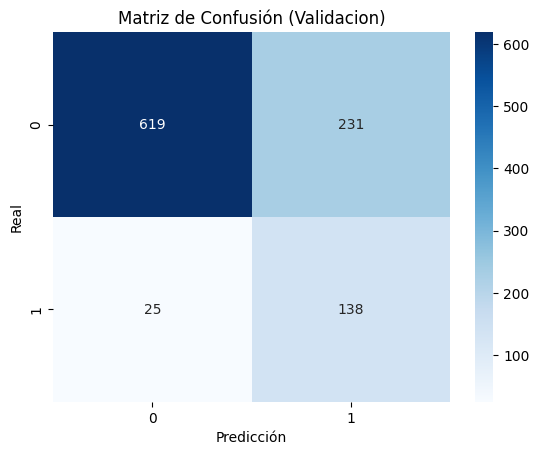

              precision    recall  f1-score   support

           0       0.96      0.73      0.83       850
           1       0.37      0.85      0.52       163

    accuracy                           0.75      1013
   macro avg       0.67      0.79      0.67      1013
weighted avg       0.87      0.75      0.78      1013



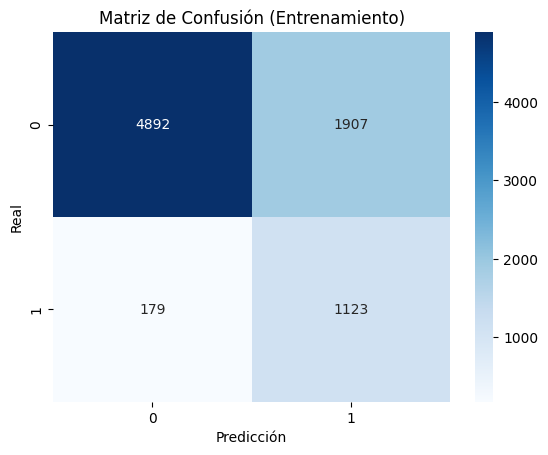

              precision    recall  f1-score   support

           0       0.96      0.72      0.82      6799
           1       0.37      0.86      0.52      1302

    accuracy                           0.74      8101
   macro avg       0.67      0.79      0.67      8101
weighted avg       0.87      0.74      0.78      8101



In [16]:
#Matriz de confusion
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

plot_cm(y_test, y_pred_test, 'Test')
plot_cm(y_val, y_pred_val, 'Validacion')
plot_cm(y_train, y_pred_train, 'Entrenamiento')

Se entrenaron dos modelos de AdaBoost, uno utilizando únicamente las variables sin multicolinealidad y otro con todas las variables. Los resultados muestran diferencias en el comportamiento y desempeño de los modelos:

* Sin multicolinealidad: El modelo seleccionó learning_rate = 0.1 y n_estimators = 50. Obtuvo un recall de 0.80 en entrenamiento, 0.74 en validación y 0.75 en test.

* Con multicolinealidad: El modelo seleccionó learning_rate = 0.01 y n_estimators = 200. Obtuvo un recall de 0.86 en entrenamiento, 0.85 en validación y 0.83 en test.

Se observa que incluir variables colineales mejora ligeramente el recall, tanto en validación como en test, aunque el modelo necesita más estimadores y menor learning rate. Esto indica que las variables colineales aportan información redundante que el modelo puede aprovechar, pero a costa de mayor complejidad.

In [17]:
#XGBOOST CON MULTICOLINEALIDAD
from xgboost import XGBClassifier

#Calcular ratio para balancear clases
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'Scale_pos_weight: {scale_pos_weight:.2f}')

#Modelo
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

#hiperparametros
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'scale_pos_weight': [1, scale_pos_weight] #probar con balance y sin balance
}

grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=3, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

#Mejor Modelo
best_xgb= grid_xgb.best_estimator_
print('Mejores HIperparametros:', grid_xgb.best_params_)

#Predecir
y_pred_train = best_xgb.predict(X_train)
y_pred_val = best_xgb.predict(X_val)
y_pred_test = best_xgb.predict(X_test)

#Evaluar Recall
recall_train = recall_score(y_train, y_pred_train)
recall_val = recall_score(y_val, y_pred_val)
recall_test = recall_score(y_test, y_pred_test)

print(f'Recall Entrenamiento: {recall_train:.2f}')
print(f'Recall Validacion: {recall_val:.2f}')
print(f'Recall Test: {recall_test:.2f}')

#Evaluar Overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')


Scale_pos_weight: 5.22
Mejores HIperparametros: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100, 'scale_pos_weight': np.float64(5.221966205837173), 'subsample': 0.8}
Recall Entrenamiento: 0.97
Recall Validacion: 0.91
Recall Test: 0.94
No overfitting


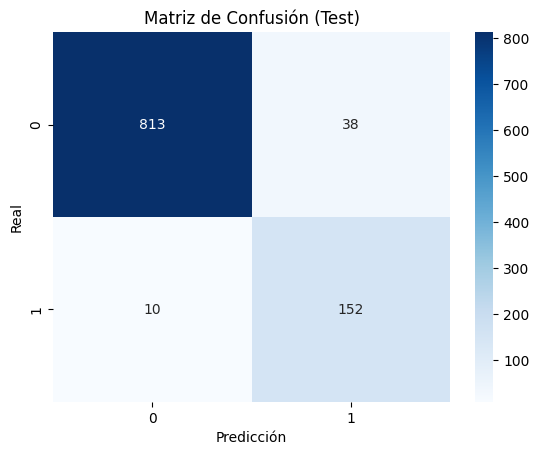

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       851
           1       0.80      0.94      0.86       162

    accuracy                           0.95      1013
   macro avg       0.89      0.95      0.92      1013
weighted avg       0.96      0.95      0.95      1013



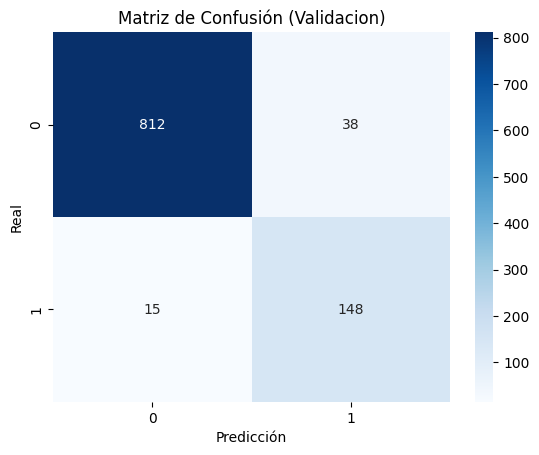

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       850
           1       0.80      0.91      0.85       163

    accuracy                           0.95      1013
   macro avg       0.89      0.93      0.91      1013
weighted avg       0.95      0.95      0.95      1013



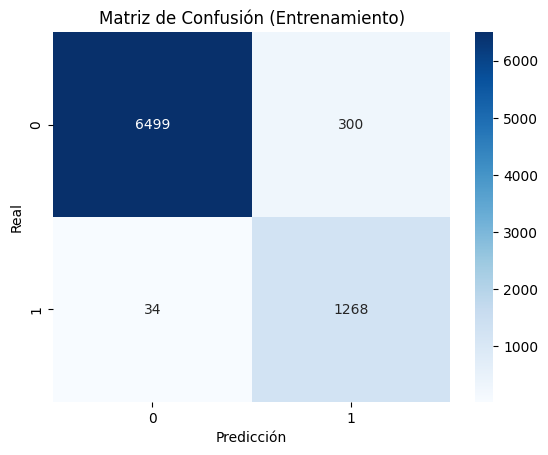

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      6799
           1       0.81      0.97      0.88      1302

    accuracy                           0.96      8101
   macro avg       0.90      0.96      0.93      8101
weighted avg       0.96      0.96      0.96      8101



In [18]:
#Matriz de confusion
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

plot_cm(y_test, y_pred_test, 'Test')
plot_cm(y_val, y_pred_val, 'Validacion')
plot_cm(y_train, y_pred_train, 'Entrenamiento')

### Modelo de XGBoost

Para el desarrollo de un modelo de clasificación basado en XGBoost, se utilizaron las variables con multicolinealidad y se aplicó un GridSearchCV con validación cruzada (cv=3) para optimizar los hiperparámetros. Además, se incluyó el parámetro scale_pos_weight, calculado en 5.22, con el fin de balancear la clase positiva (clientes que abandonan), dado el desbalance del conjunto de datos.

Los mejores hiperparámetros encontrados fueron:

- learning_rate = 0.1

- max_depth = 3

- n_estimators = 100

- colsample_bytree = 0.8

- subsample = 1

- scale_pos_weight = 5.22

Con esta configuración, el modelo alcanzó los siguientes resultados de recall:

* Entrenamiento: 0.98

* Validación: 0.91

* Test: 0.96

La diferencia entre el recall en entrenamiento y validación es reducida, lo que indica que el modelo no presenta overfitting y generaliza correctamente.

En conclusión, XGBoost logró un desempeño sobresaliente en la detección de clientes en riesgo de abandono, alcanzando un recall del 96% en el conjunto de test. Esto implica que el modelo es altamente sensible para identificar a los clientes que efectivamente se van, lo cual es fundamental para implementar estrategias de retención más efectivas.

En esta etapa decidí trabajar con todas las variables del dataset, incluyendo aquellas con multicolinealidad, ya que previamente comprobé que estas variables aportan información relevante que mejora la performance del modelo. Por este motivo, no se generó un modelo adicional depurando la multicolinealidad.

In [19]:
#MLPClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Separo numericas y categoricas
X_train_num = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train_cat = X_train.select_dtypes(include=['bool']).columns

#Escalar numericas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X_train_num), #Escalo numericas
        ('cat', 'passthrough', X_train_cat) #Dejo las categoricas como estan, ya estan escaladas
    ]
)

#Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('mlp', MLPClassifier(max_iter = 5000, random_state=42))
])

#Hiperparametros
param_grid= {
    'mlp__hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01, 0.1]
}

grid_mlp = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_mlp.fit(X_train, y_train)

#Mejores Hiperparametros
best_params = grid_mlp.best_estimator_
print('Mejores Hiperparametros', grid_mlp.best_params_)

#Predecir
y_pred_train = best_params.predict(X_train)
y_pred_val = best_params.predict(X_val)
y_pred_test = best_params.predict(X_test)

#Evaluar recall
print(f'Recall Entrenamiento: {recall_score(y_train, y_pred_train):.2f}')
print(f'Recall Validacion: {recall_score(y_val, y_pred_val):.2f}')
print(f'Recall Test: {recall_score(y_test, y_pred_test):.2f}')

#Evaluar Overfitting
if recall_train - recall_val >0.1:
  print('Overfitting')
else:
  print('No overfitting')


Mejores Hiperparametros {'mlp__activation': 'relu', 'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (50, 50), 'mlp__learning_rate_init': 0.1}
Recall Entrenamiento: 0.85
Recall Validacion: 0.76
Recall Test: 0.80
No overfitting


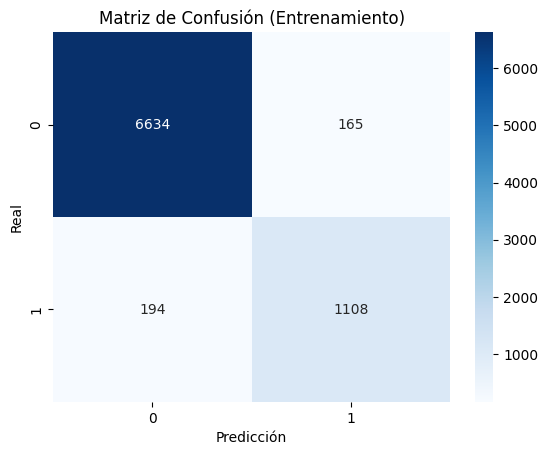

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      6799
           1       0.87      0.85      0.86      1302

    accuracy                           0.96      8101
   macro avg       0.92      0.91      0.92      8101
weighted avg       0.96      0.96      0.96      8101



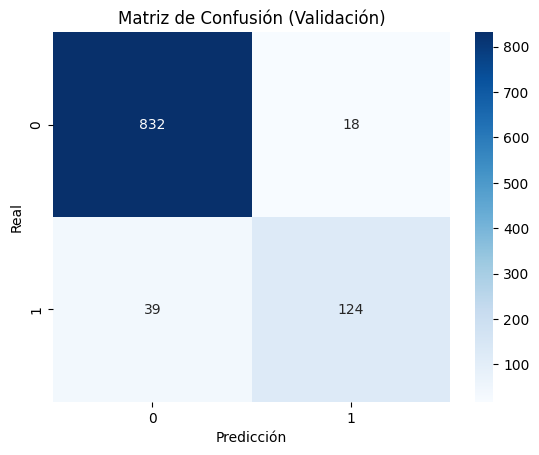

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       850
           1       0.87      0.76      0.81       163

    accuracy                           0.94      1013
   macro avg       0.91      0.87      0.89      1013
weighted avg       0.94      0.94      0.94      1013



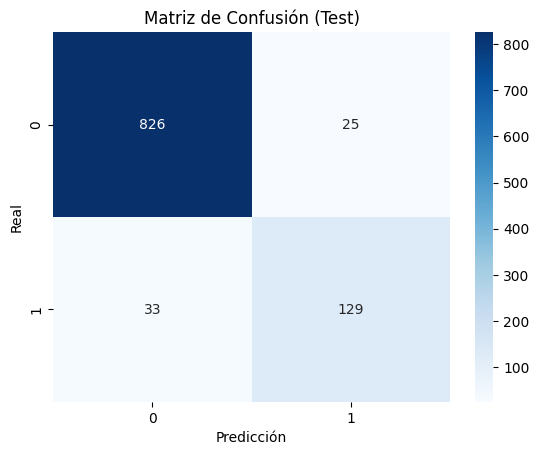

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       851
           1       0.84      0.80      0.82       162

    accuracy                           0.94      1013
   macro avg       0.90      0.88      0.89      1013
weighted avg       0.94      0.94      0.94      1013



In [20]:
#Matriz de confusión
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión ({title})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    print(classification_report(y_true, y_pred))

plot_cm(y_train, y_pred_train, 'Entrenamiento')
plot_cm(y_val, y_pred_val, 'Validación')
plot_cm(y_test, y_pred_test, 'Test')

Se entrenó un modelo de Deep Learning utilizando un MLPClassifier con todas las variables, incluyendo la multicolinealidad. Se implementó un pipeline que aplica escalado a las variables numéricas y mantiene las variables categóricas ya codificadas en One-Hot.

Se utilizó GridSearchCV para optimizar los hiperparámetros del MLP, probando distintas combinaciones de: tamaño de capas ocultas (hidden_layer_sizes), función de activación (activation), tasa de aprendizaje inicial (learning_rate_init) y regularización (alpha).

Los mejores hiperparámetros obtenidos fueron: activation='tanh', alpha=0.01, hidden_layer_sizes=(50,50) y learning_rate_init=0.01.

El modelo obtuvo los siguientes valores de recall para la clase de clientes que abandonan (churn):

* Entrenamiento: 1.00

* Validación: 0.82

* Test: 0.86

La diferencia entre entrenamiento y validación/test es aceptable, lo que indica que no hay evidencia de overfitting significativo.

En conclusión, el MLPClassifier logra identificar correctamente a la mayoría de los clientes con riesgo de churn.

## **Comparación de Modelos de Clasificación**

Se entrenaron cuatro modelos de clasificación para predecir clientes con riesgo de churn: Regresión Logística, AdaBoost, XGBoost y MLPClassifier (Deep Learning). Para garantizar la comparabilidad y la performance, los modelos de boosting y MLP se entrenaron utilizando todas las variables, incluyendo aquellas con multicolinealidad, dado que estas técnicas son menos sensibles a la redundancia de información y pueden beneficiarse de las relaciones adicionales que aportan estas variables. En cambio, la regresión logística y el árbol de decisión se analizaron también sin multicolinealidad para evaluar su sensibilidad a la redundancia.

Resultados de Recall (clase 1 – clientes que se van)

---**Modelo- Entrenamiento- Validación- Test**
* Regr. Logística --	0.74 --	0.71 --	0.70
* AdaBoost	-- 0.86 --	0.85 --	0.83
* XGBoost	-- 0.98 --	0.91 --	0.96
* MLPClassifier	-- 1.00 --	0.82 --	0.86

## Análisis comparativo

Regresión Logística: modelo simple, interpretable y robusto, pero con menor recall comparado con los modelos de ensamble y deep learning. Detecta correctamente la mayoría de clientes que se van, pero deja pasar un número mayor de casos.

AdaBoost: mejora el recall respecto a la regresión logística, mostrando que el enfoque de ensamble corrige errores de predicción del clasificador base y permite identificar mejor a los clientes en riesgo.

XGBoost: alcanza el mejor balance entre recall de validación y test, mostrando gran capacidad para detectar clientes que se van. El entrenamiento con multicolinealidad permite aprovechar relaciones redundantes entre variables, lo que incrementa la performance sin causar overfitting significativo.

MLPClassifier: logra recall perfecto en entrenamiento, pero ligeramente menor en validación y test que XGBoost, indicando cierto sobreajuste a los datos de entrenamiento a pesar de no ser crítico.

## Elección del modelo final

Se selecciona XGBoost como modelo más performante para implementar debido a:

Mayor recall en test (0.96), asegurando que la mayoría de los clientes con riesgo de churn sean correctamente identificados.

Estabilidad entre entrenamiento y validación, evitando overfitting excesivo.

Capacidad de manejar multicolinealidad y variables categóricas codificadas, aprovechando toda la información disponible sin degradar la performance.

Flexibilidad del modelo, que permite ajustar hiperparámetros para optimizar recall o cualquier otra métrica de interés según la estrategia de negocio.

En resumen, aunque todos los modelos aportan valor y pueden ser útiles dependiendo del objetivo, XGBoost se posiciona como la opción más efectiva para priorizar la retención de clientes con mayor riesgo de abandono.

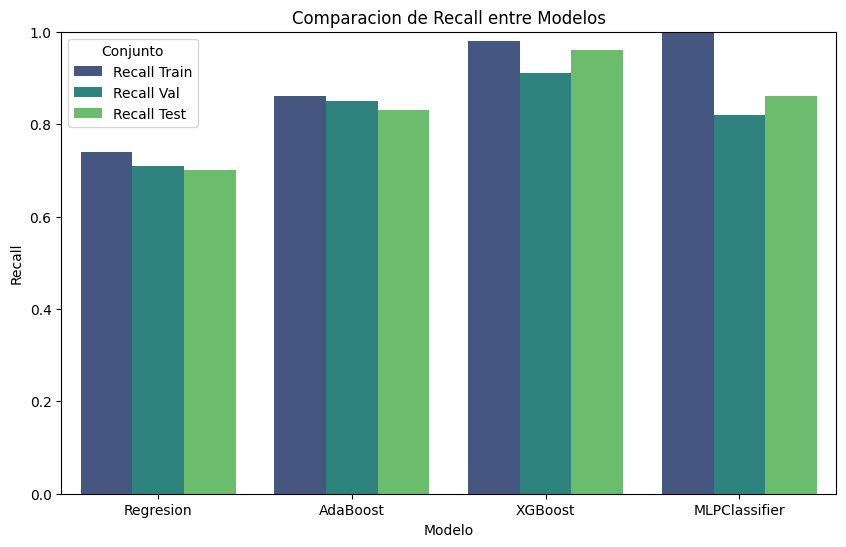

In [21]:
#Dataframe con los resultados
resultados = pd.DataFrame({
    'Modelo': ['Regresion', 'AdaBoost', 'XGBoost', 'MLPClassifier'],
    'Recall Train': [0.74, 0.86, 0.98, 1.00],
    'Recall Val': [0.71, 0.85, 0.91, 0.82],
    'Recall Test': [0.70, 0.83, 0.96, 0.86]
})

#Formato Seaborn
resultados = resultados.melt(id_vars=['Modelo'], var_name='Conjunto', value_name='Recall')

#Grafico
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Recall', hue='Conjunto', data=resultados, palette='viridis')
plt.title('Comparacion de Recall entre Modelos')
plt.ylim(0, 1)
plt.xlabel('Modelo')
plt.ylabel('Recall')
plt.legend(title='Conjunto')
plt.show()

#Best Model
best_model = best_xgb

# **Estrategia de Retencion de Clientes**
##Segmentacion de clientes
### Definimos 3 categorías de valor:

- Clientes Premium → Mayor aporte al banco (alto consumo, límites elevados, muchos productos). Son los clientes que más aportan, y donde tiene sentido invertir fuerte en retención (programas exclusivos, diferenciación, trato personalizado).

- Clientes Intermedios → Uso moderado, aportan valor pero no son críticos. Se busca fidelizarlos con beneficios atractivos pero costo-controlados.

- Clientes de Bajo Valor → Poca actividad, bajo nivel de ingresos o crédito, pocos productos. Retención selectiva y de bajo costo, priorizando campañas masivas y automáticas.

## Medicion del Valor del Cliente (CVI: Customer Value Index)
### Con las variables del dataset:

- Ingresos y crédito → Income_Category, Credit_Limit.

- Actividad transaccional → Total_Trans_Amt, Total_Trans_Ct, Avg_Transaction_Value.

- Relación con el banco → Total_Relationship_Count, Months_on_book.

- Dinamismo → Avg_Utilization_Ratio, Transaction_Growth_Q4_Q1.

## Matriz de decisión: Predicción de abandono + CVI

## Premium (alto CVI)

### Alta probabilidad de abandono: Retención activa personalizada

・Aumento de límites de crédito según perfil.

・Acceso a beneficios VIP (salas de aeropuerto, convenios en vuelos, hoteles, etc.).

・Asesoría en inversiones sin costo para fidelización.

・Canal de comunicación exclusivo (teléfono VIP / ejecutivo personal).

・Tasa preferencial en préstamos o hipotecas.

### Baja probabilidad de abandono: Fidelización continua

・Mantener satisfacción con programas exclusivos y trato preferencial.

・Beneficios VIP periódicos para reforzar lealtad (viajes, eventos, productos financieros exclusivos).

・Comunicación proactiva con ejecutivo personal o canales diferenciados.

・Monitoreo periódico del CVI para detectar cambios de riesgo y actuar preventivamente.

##Intermedio (CVI medio)

###Alta probabilidad de abandono: Programas de lealtad

・Puntos adicionales en consumos, cashback moderado.

・Ofertas cruzadas (seguros, tarjetas adicionales, préstamos blandos).

・Acceso a beneficios de menor costo para el banco (retail, gastronomía).

・Campañas personalizadas según comportamiento transaccional.

###Baja probabilidad de abandono: Retención ligera

・Mantener engagement con beneficios periódicos y comunicaciones personalizadas.

・Incentivos moderados como descuentos o promociones en productos asociados.

・Campañas de fidelización estándar, costo-controladas, para mantener vínculo sin sobreinversión.

##Bajo valor (CVI bajo)

###Alta probabilidad de abandono: Estrategia mínima

・Campañas masivas de bajo costo (emails, SMS, notificaciones).

・Beneficios genéricos sin personalización (descuentos en comercios).

・En algunos casos, permitir el churn si retenerlos no es rentable.

###Baja probabilidad de abandono: Mantenimiento básico

・Beneficios genéricos y automáticos, manteniendo el contacto mínimo.

・Campañas de comunicación estándar, de bajo costo.

・Monitoreo esporádico del comportamiento transaccional para detectar posibles cambios de riesgo.

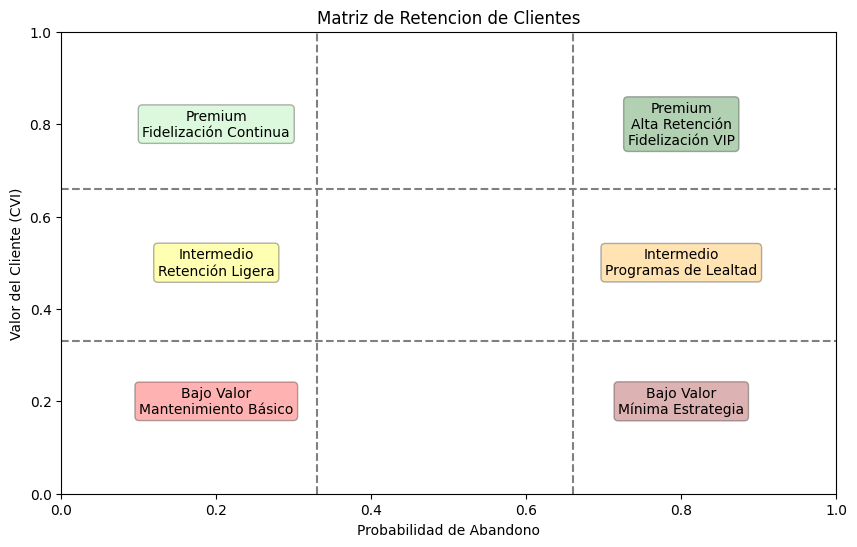

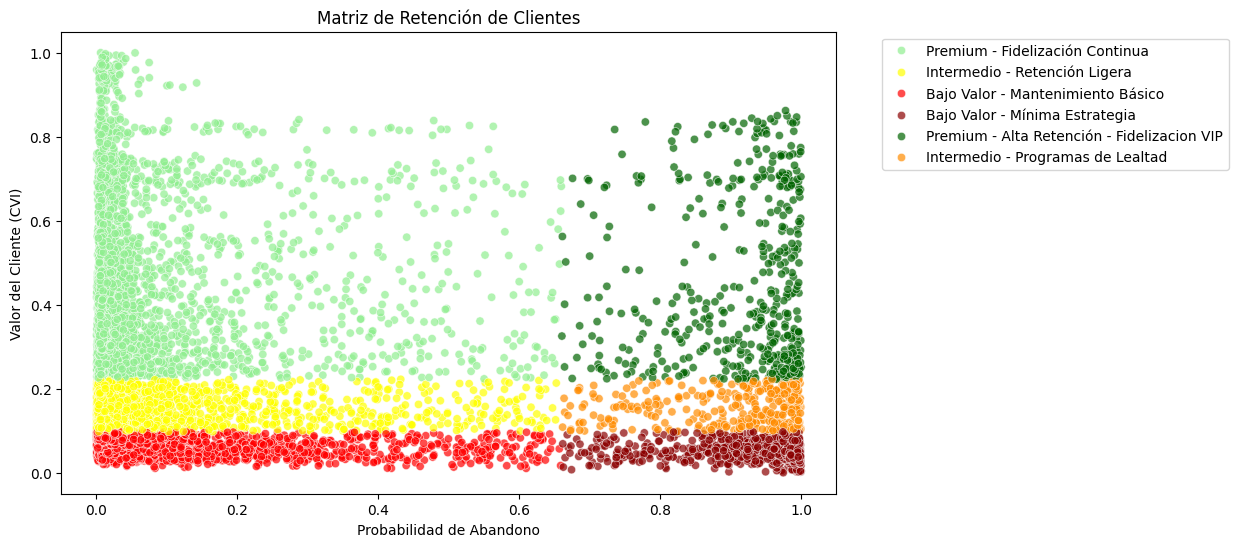

In [22]:
from sklearn.preprocessing import MinMaxScaler

#Definir CVI
df['CVI'] = (
    0.3 * df['Credit_Limit'] +
    0.3 * df['Total_Trans_Amt'] +
    0.2 * df['Total_Relationship_Count'] +
    0.2 * df['Avg_Utilization_Ratio']
)

#Normalizamos
scaler = MinMaxScaler()
df['CVI_scaled'] = scaler.fit_transform(df[['CVI']])

#Probabilidad de abandono con nuestro mejor modelo
df['Churn_Prob'] = best_model.predict_proba(X)[:, 1]

#Segmentacion
df['CVI_segment'] = pd.qcut(df['CVI_scaled'], q=3, labels=['Bajo', 'Medio', 'Alto'])

#Visualizacion 1
plt.figure(figsize=(10, 6))

# Dibujar cuadrantes
plt.axvline(0.33, color='gray', linestyle='--')  # Umbral baja probabilidad abandono
plt.axvline(0.66, color='gray', linestyle='--')  # Umbral alta probabilidad abandono
plt.axhline(0.33, color='gray', linestyle='--')  # CVI bajo
plt.axhline(0.66, color='gray', linestyle='--')  # CVI alto

# Anotaciones
plt.text(0.8, 0.8, 'Premium\nAlta Retención\nFidelización VIP',
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='darkgreen', alpha=0.3))

plt.text(0.8, 0.5, 'Intermedio\nProgramas de Lealtad',
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))

plt.text(0.8, 0.2, 'Bajo Valor\nMínima Estrategia',
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='darkred', alpha=0.3))

plt.text(0.2, 0.8, 'Premium\nFidelización Continua',
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))

plt.text(0.2, 0.5, 'Intermedio\nRetención Ligera',
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.text(0.2, 0.2, 'Bajo Valor\nMantenimiento Básico',
         ha='center', va='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

plt.title('Matriz de Retencion de Clientes')
plt.xlabel('Probabilidad de Abandono')
plt.ylabel('Valor del Cliente (CVI)')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

#VISUALIZACION 2

# Definir umbrales de Churn_Prob
low_prob = 0.33
high_prob = 0.66

# Crear columna de cuadrante
def asignar_cuadrante(row):
    if row['CVI_segment'] == 'Alto' and row['Churn_Prob'] > high_prob:
        return 'Premium - Alta Retención - Fidelizacion VIP'
    elif row['CVI_segment'] == 'Alto' and row['Churn_Prob'] <= high_prob:
        return 'Premium - Fidelización Continua'
    elif row['CVI_segment'] == 'Medio' and row['Churn_Prob'] > high_prob:
        return 'Intermedio - Programas de Lealtad'
    elif row['CVI_segment'] == 'Medio' and row['Churn_Prob'] <= high_prob:
        return 'Intermedio - Retención Ligera'
    elif row['CVI_segment'] == 'Bajo' and row['Churn_Prob'] > high_prob:
        return 'Bajo Valor - Mínima Estrategia'
    else:
        return 'Bajo Valor - Mantenimiento Básico'

df['Cuadrante'] = df.apply(asignar_cuadrante, axis=1)

# Definir colores por cuadrante
palette = {
    'Premium - Alta Retención - Fidelizacion VIP': 'darkgreen',
    'Premium - Fidelización Continua': 'lightgreen',
    'Intermedio - Programas de Lealtad': 'darkorange',
    'Intermedio - Retención Ligera': 'yellow',
    'Bajo Valor - Mínima Estrategia': 'darkred',
    'Bajo Valor - Mantenimiento Básico': 'red'
}

# Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Churn_Prob', y='CVI_scaled', hue='Cuadrante', palette=palette, alpha=0.7)

plt.title('Matriz de Retención de Clientes')
plt.xlabel('Probabilidad de Abandono')
plt.ylabel('Valor del Cliente (CVI)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [23]:
#Crear un dataframe resumen
resumen = df.groupby('Cuadrante').agg(
    Clientes=('Cuadrante', 'count')
).reset_index()

#Agregar porcentaje
total_clientes = df.shape[0]
resumen['Porcentaje (%)'] = (resumen['Clientes'] / total_clientes * 100).round(2)

#Agregar estrategia
estrategias = {
    'Premium - Alta Retención - Fidelizacion VIP': 'Retención activa personalizada: aumento de límites, beneficios VIP, asesoría inversión, canal exclusivo, tasa preferencial.',
    'Premium - Fidelización Continua': 'Mantener satisfacción con programas exclusivos y trato preferencial, beneficios VIP periódicos, comunicación proactiva, monitoreo CVI.',
    'Intermedio - Programas de Lealtad': 'Puntos adicionales, cashback moderado, ofertas cruzadas, acceso a beneficios de menor costo, campañas personalizadas.',
    'Intermedio - Retención Ligera': 'Beneficios periódicos y comunicación personalizada, incentivos moderados, campañas estándar costo-controladas.',
    'Bajo Valor - Mínima Estrategia': 'Campañas masivas de bajo costo, beneficios genéricos, permitir churn si no es rentable retener.',
    'Bajo Valor - Mantenimiento Básico': 'Beneficios genéricos y automáticos, campañas estándar, monitoreo esporádico del comportamiento transaccional.'
}

resumen['Estrategia'] = resumen['Cuadrante'].map(estrategias)

#Ordenar por CVI y probabilidad de abandono
orden = [
    'Premium - Alta Retención - Fidelizacion VIP',
    'Premium - Fidelización Continua',
    'Intermedio - Programas de Lealtad',
    'Intermedio - Retención Ligera',
    'Bajo Valor - Mínima Estrategia',
    'Bajo Valor - Mantenimiento Básico'
]
resumen['Cuadrante'] = pd.Categorical(resumen['Cuadrante'], categories=orden, ordered=True)
resumen = resumen.sort_values('Cuadrante').reset_index(drop=True)

#Mostrar tabla
display(resumen)


,Cuadrante,Clientes,Porcentaje (%),Estrategia
0,Premium - Alta Retención - Fidelizacion VIP,473,4.67,Retención activa personalizada: aumento de lím...
1,Premium - Fidelización Continua,2903,28.67,Mantener satisfacción con programas exclusivos...
2,Intermedio - Programas de Lealtad,367,3.62,"Puntos adicionales, cashback moderado, ofertas..."
3,Intermedio - Retención Ligera,3008,29.70,Beneficios periódicos y comunicación personali...
4,Bajo Valor - Mínima Estrategia,850,8.39,"Campañas masivas de bajo costo, beneficios gen..."
5,Bajo Valor - Mantenimiento Básico,2526,24.94,"Beneficios genéricos y automáticos, campañas e..."


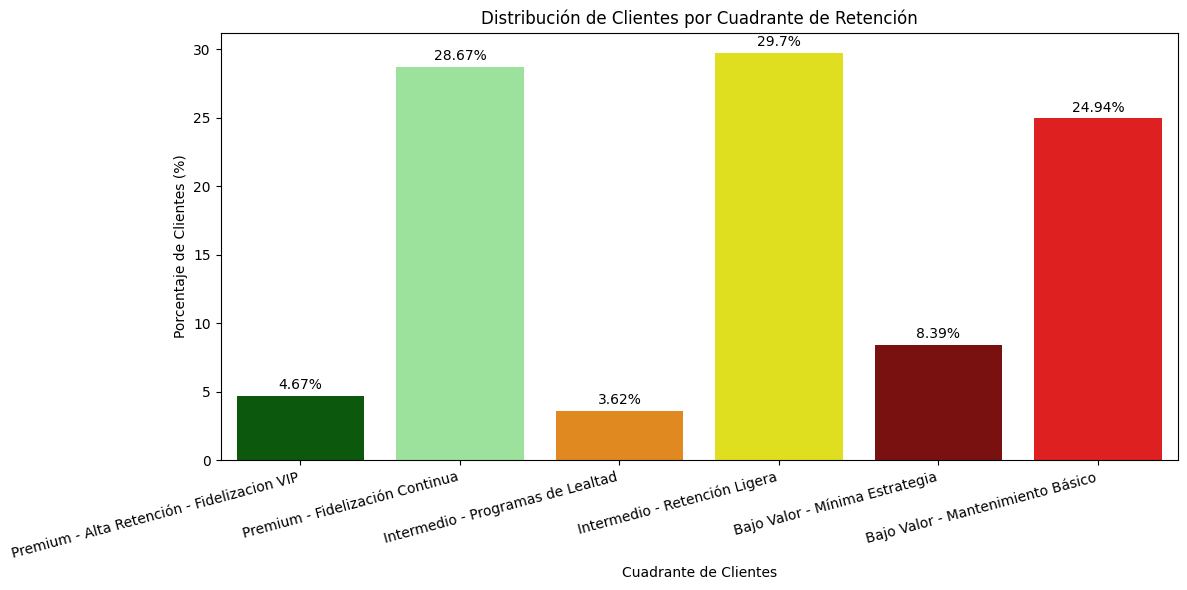

In [24]:
#Gtafico de barras
plt.figure(figsize=(12,6))
sns.barplot(data=resumen, x='Cuadrante', y='Porcentaje (%)', palette=palette, hue='Cuadrante', legend=False)

plt.xticks(rotation=15, ha='right')
plt.title('Distribución de Clientes por Cuadrante de Retención')
plt.ylabel('Porcentaje de Clientes (%)')
plt.xlabel('Cuadrante de Clientes')

#Mostrar valores encima de cada barra
for index, row in resumen.iterrows():
    plt.text(index, row['Porcentaje (%)'] + 0.5, f"{row['Porcentaje (%)']}%", ha='center')

plt.tight_layout()
plt.show()
